### STEP1: IMPORTING

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
from sklearn.preprocessing import LabelEncoder,MinMaxScaler
import warnings
warnings.filterwarnings("ignore")  

### STEP2: LOAD DATASET

We are using the Bank Marketing dataset which contains information about customers, their demographics, financial data, and marketing campaign interactions. Our goal is to predict whether a customer will subscribe to a term deposit.

In [142]:
data = pd.read_csv("bank marketing.csv")
data

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,60.0,admin.,married,secondary,no,2348.0,yes,no,unknown,3,may,1041,4,2,0,unknown,1
1,58.0,admin.,married,secondary,no,41.0,no,no,unknown,4,may,1464,0,2,5,unknown,1
2,36.0,technician,married,secondary,no,1274.0,yes,no,unknown,10,may,1386,2,4,2,unknown,1
3,52.0,services,married,secondary,no,2477.0,yes,no,unknown,4,may,580,4,3,5,unknown,1
4,49.0,admin.,married,tertiary,no,188.0,no,no,unknown,4,may,669,2,3,3,unknown,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,49.0,technician,married,secondary,no,1835.0,yes,yes,cellular,15,aug,223,3,6,1,unknown,0
49996,50.0,unknown,married,unknown,no,552.0,no,no,telephone,24,jan,74,4,1,2,unknown,0
49997,42.0,admin.,married,secondary,no,1097.0,yes,yes,cellular,5,feb,178,4,212,6,failure,0
49998,48.0,unemployed,married,tertiary,no,1148.0,no,yes,cellular,19,nov,783,5,1,1,unknown,0


In [150]:
data["job"].value_counts()                                   

job
management       11567
blue-collar       8512
technician        8155
admin.            5976
services          4032
retired           3621
self-employed     1809
student           1689
unemployed        1634
entrepreneur      1468
housemaid         1216
unknown            321
Name: count, dtype: int64

In [152]:
data["education"].value_counts()                                               

education
secondary    24386
tertiary     16800
primary       6563
unknown       2251
Name: count, dtype: int64

In [153]:
data["contact"].value_counts()                                                 

contact
cellular     36575
unknown       9933
telephone     3492
Name: count, dtype: int64

In [154]:
data["month"].value_counts()                                                 

month
may    12241
aug     6779
jul     6690
jun     5442
apr     4269
nov     4183
feb     3547
oct     1892
sep     1545
jan     1520
mar     1352
dec      540
Name: count, dtype: int64

In [155]:
data["poutcome"].value_counts()                                               

poutcome
unknown    36745
failure     5535
success     5264
other       2456
Name: count, dtype: int64

### Dataset Overview

- Number of rows and columns
- Features include:
    - Demographics: Age, Gender, Marital Status
    - Financial: Income, KidHome, TeenHome
    - Marketing: previous contacts, campaign, pdays, accepted campaigns
- Target: Response (Yes/No)


In [3]:
print("Rows, Columns",data.shape)                                              

Rows, Columns (50000, 17)


In [4]:
print("\nColumn Names:\n",data.columns)                                        


Column Names:
 Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'deposit'],
      dtype='object')


In [24]:
print("\nData Types:\n",data.dtypes)                                         


Data Types:
 age          float64
job           object
marital       object
education     object
default       object
balance      float64
housing       object
loan          object
contact       object
day            int64
month         object
duration       int64
campaign       int64
pdays          int64
previous       int64
poutcome      object
deposit        int64
dtype: object


### STEP3: EDA(Exploratory Data Analysis)

Exploratory Data Analysis (EDA) is performed using SQLite3 to create a structured database table from the bank marketing dataset. This allows efficient querying and aggregation of customer and campaign data, helping to uncover patterns and insights that guide further analysis and model development.

In [6]:
import sqlite3  #import sqlite                

In [7]:
a = sqlite3.connect("bank marketing.db") #sqlite databse create cheyunnu    
data.to_sql("bank_data",a,index=False,if_exists="replace") #Data frame nne sql table llek convert cheyunnu ,#ith illathe undakkam pandas create cheyyum
tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'",a) #sqlite systme table anne master #database lle full tables nne fetch cheyum
print(tables) 

                 name
0  bank marketing.csv
1           bank_data


In [8]:
querry = """SELECT deposit, COUNT(*) AS total_customers 
FROM bank_data 
GROUP BY deposit
"""
pd.read_sql(querry,a)                                                         

,deposit,total_customers
0,0,23555
1,1,26445


In [9]:
qury = """ SELECT campaign, deposit, COUNT(*) as count
FROM bank_data
GROUP BY campaign,deposit
ORDER BY campaign 
"""
pd.read_sql(qury,a)                                                                 

,campaign,deposit,count
0,0,0,1891
1,0,1,2260
2,1,0,3812
3,1,1,4629
4,2,0,3727
...,...,...,...
76,46,0,2
77,62,0,1
78,64,0,1
79,65,0,1


In [10]:
quryy = """SELECT poutcome, deposit, COUNT(*) AS total_count
FROM bank_data 
GROUP BY poutcome,deposit """
pd.read_sql(quryy,a)                                                            

,poutcome,deposit,total_count
0,failure,0,2445
1,failure,1,3090
2,other,0,921
3,other,1,1535
4,success,0,374
5,success,1,4890
6,unknown,0,19815
7,unknown,1,16930


In [11]:
age = pd.read_sql("""SELECT * FROM bank_data WHERE age > 60 ORDER BY age""",a)     
age                                                                            

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,61.0,management,married,tertiary,no,831.0,yes,yes,unknown,7,may,1204,1,2,5,unknown,1
1,61.0,technician,married,tertiary,no,2.0,no,no,unknown,9,may,846,3,6,1,unknown,1
2,61.0,unemployed,married,primary,no,NaN,no,no,cellular,32,jul,1723,2,1,3,unknown,1
3,61.0,admin.,married,secondary,no,1698.0,no,no,cellular,19,aug,790,11,6,4,unknown,1
4,61.0,blue-collar,married,primary,no,542.0,no,no,cellular,21,aug,1150,10,4,2,unknown,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3651,96.0,retired,married,tertiary,no,774.0,no,no,cellular,3,aug,473,5,10,4,success,1
3652,96.0,retired,married,unknown,no,771.0,no,no,cellular,23,jan,164,9,100,3,success,1
3653,96.0,retired,married,unknown,no,780.0,no,no,cellular,21,jan,161,4,93,1,success,1
3654,98.0,retired,divorced,primary,no,NaN,no,no,telephone,22,apr,202,19,2,2,unknown,1


In [12]:
pd.read_sql(
    """
    SELECT 
        MIN(age) AS min_age,
        MAX(age) AS max_age,
        MIN(campaign) AS min_campaign,
        MAX(campaign) AS max_campaign
    FROM bank_data;
    """,
    a
)

,min_age,max_age,min_campaign,max_campaign
0,13.0,98.0,0,68


In [13]:
data.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        50000 non-null  float64
 1   job        50000 non-null  object 
 2   marital    50000 non-null  object 
 3   education  50000 non-null  object 
 4   default    50000 non-null  object 
 5   balance    47440 non-null  float64
 6   housing    50000 non-null  object 
 7   loan       50000 non-null  object 
 8   contact    50000 non-null  object 
 9   day        50000 non-null  int64  
 10  month      50000 non-null  object 
 11  duration   50000 non-null  int64  
 12  campaign   50000 non-null  int64  
 13  pdays      50000 non-null  int64  
 14  previous   50000 non-null  int64  
 15  poutcome   50000 non-null  object 
 16  deposit    50000 non-null  int64  
dtypes: float64(2), int64(6), object(9)
memory usage: 6.5+ MB


In [14]:
data.describe().T                                                             

,count,mean,std,min,25%,50%,75%,max
age,50000.0,41.248000,12.485748,13.0,32.0,39.0,49.0,98.0
balance,47440.0,1600.912226,3229.883797,0.0,179.0,586.5,1768.0,81209.0
day,50000.0,15.673420,8.875732,0.0,8.0,15.0,23.0,36.0
duration,50000.0,389.277760,355.731518,0.0,147.0,268.0,528.0,3885.0
campaign,50000.0,3.633300,3.157555,0.0,1.0,3.0,5.0,68.0
pdays,50000.0,55.942980,108.610193,0.0,2.0,4.0,80.0,854.0
previous,50000.0,3.113060,2.538197,0.0,1.0,3.0,4.0,62.0
deposit,50000.0,0.528900,0.499169,0.0,0.0,1.0,1.0,1.0


In [25]:
data.isna().sum()                                                         

age             0
job             0
marital         0
education       0
default         0
balance      2560
housing         0
loan            0
contact         0
day             0
month           0
duration        0
campaign        0
pdays           0
previous        0
poutcome        0
deposit         0
dtype: int64

In [26]:
data["deposit"].value_counts()                                                      

deposit
1    26445
0    23555
Name: count, dtype: int64

In [27]:
data["job"].value_counts()                                                        

job
management       11567
blue-collar       8512
technician        8155
admin.            5976
services          4032
retired           3621
self-employed     1809
student           1689
unemployed        1634
entrepreneur      1468
housemaid         1216
unknown            321
Name: count, dtype: int64

In [28]:
pd.crosstab(data["job"],data["deposit"])  #Crosstab = comparison table between two categories. freq comaprison 

deposit,0,1
job,,
admin.,2801,3175
blue-collar,4966,3546
entrepreneur,845,623
housemaid,662,554
management,5073,6494
retired,1056,2565
self-employed,868,941
services,2208,1824
student,360,1329


In [29]:
pd.crosstab(data["education"],data["deposit"])                                                  

deposit,0,1
education,,
primary,3608,2955
secondary,12117,12269
tertiary,6835,9965
unknown,995,1256


In [30]:
data.groupby("deposit")["balance"].mean()                                     

deposit
0    1342.766282
1    1830.983615
Name: balance, dtype: float64

In [31]:
data                                                                                                                  

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,60.0,admin.,married,secondary,no,2348.0,yes,no,unknown,3,may,1041,4,2,0,unknown,1
1,58.0,admin.,married,secondary,no,41.0,no,no,unknown,4,may,1464,0,2,5,unknown,1
2,36.0,technician,married,secondary,no,1274.0,yes,no,unknown,10,may,1386,2,4,2,unknown,1
3,52.0,services,married,secondary,no,2477.0,yes,no,unknown,4,may,580,4,3,5,unknown,1
4,49.0,admin.,married,tertiary,no,188.0,no,no,unknown,4,may,669,2,3,3,unknown,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,49.0,technician,married,secondary,no,1835.0,yes,yes,cellular,15,aug,223,3,6,1,unknown,0
49996,50.0,unknown,married,unknown,no,552.0,no,no,telephone,24,jan,74,4,1,2,unknown,0
49997,42.0,admin.,married,secondary,no,1097.0,yes,yes,cellular,5,feb,178,4,212,6,failure,0
49998,48.0,unemployed,married,tertiary,no,1148.0,no,yes,cellular,19,nov,783,5,1,1,unknown,0


In [32]:
data.groupby("deposit")["campaign"].mean()                                                                 

deposit
0    3.904606
1    3.391643
Name: campaign, dtype: float64

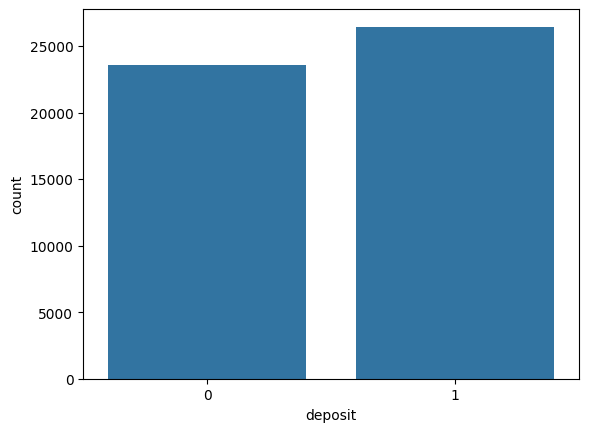

In [33]:
sns.countplot(x="deposit",data=data)
plt.show()                                                                                                 

#### JOB DISTRIBUTION

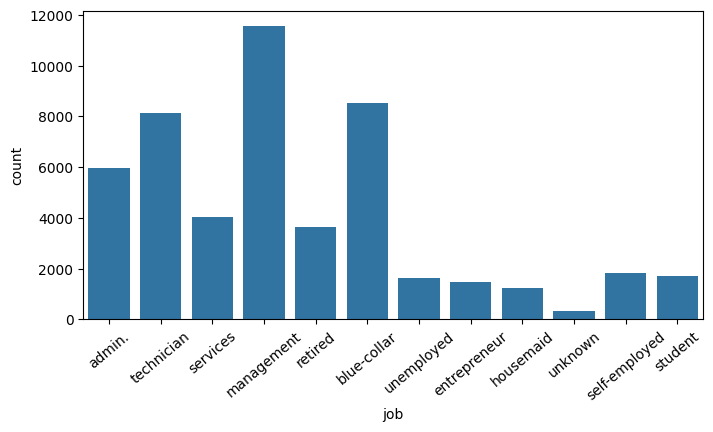

In [34]:
plt.figure(figsize=(8,4))
sns.countplot(x="job",data=data)                                    
plt.xticks(rotation=40)
plt.show()                                                          

#### JOB VS DEPOSIT

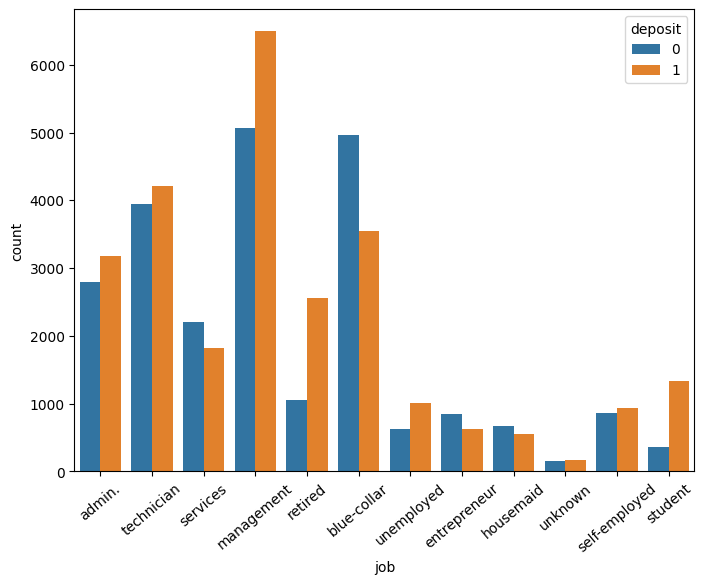

In [35]:
plt.figure(figsize=(8,6))
sns.countplot(x="job",hue="deposit",data=data)                          
plt.xticks(rotation=40)
plt.show()

This chart compares term deposit subscription across different job categories. It helps identify which customer professions are more likely to subscribe, with rotated x-axis labels used for better readability.

#### AGE DISTRIBUTION

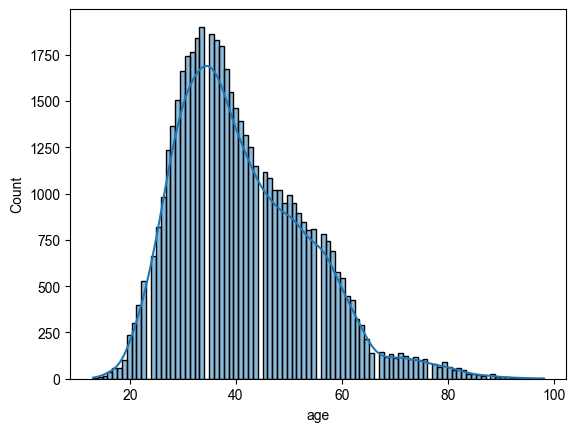

In [36]:
sns.histplot(data["age"],kde=True,linewidth=1)
sns.set_style("whitegrid")                                                       
plt.show()

#### Countplots of Categorical Variables

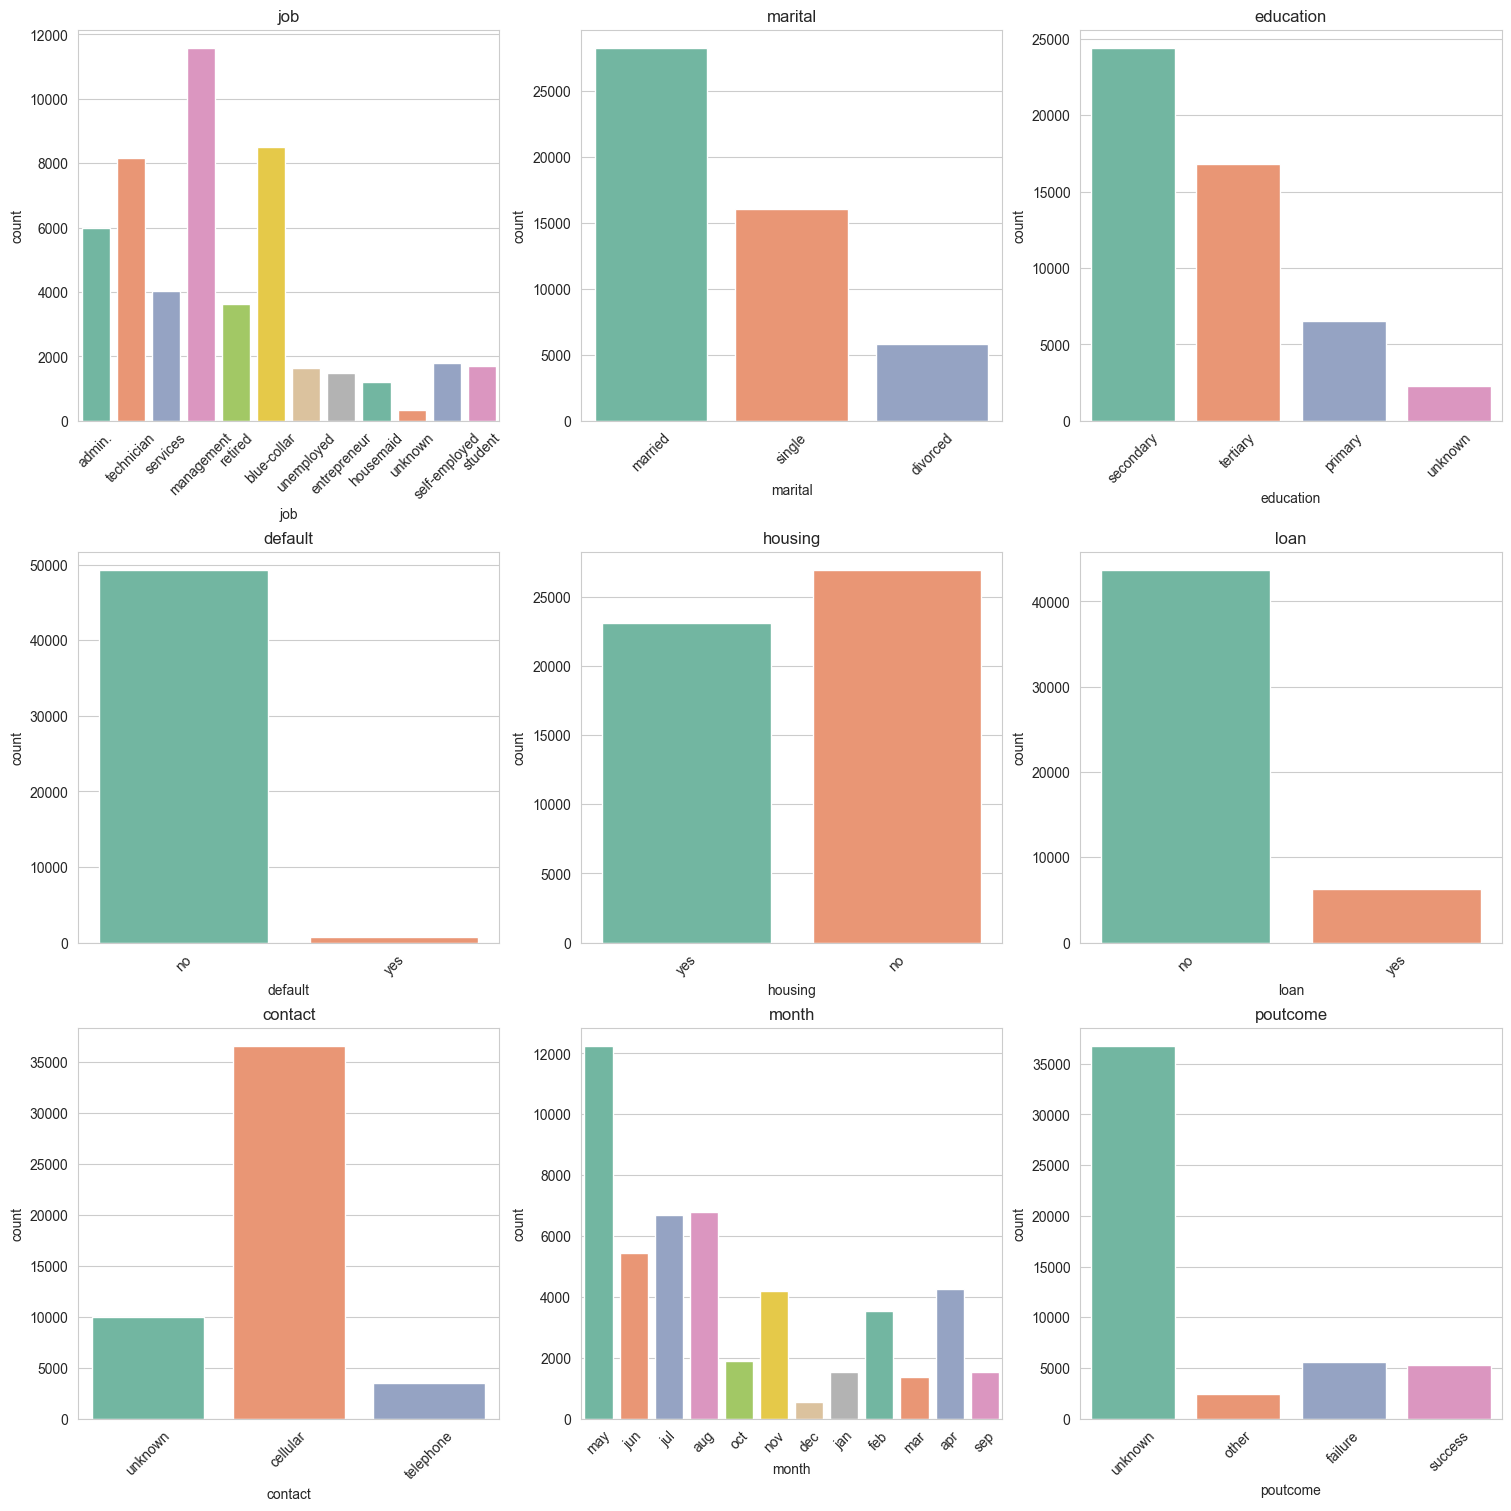

In [37]:
cat_cols = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']
plt.figure(figsize=(15,15), layout='constrained')

for i in range(len(cat_cols)):
    plt.subplot(3,3,i+1)                                                  
    sns.countplot(x=cat_cols[i], data=data, palette='Set2')
    plt.title(cat_cols[i])
    plt.xticks(rotation=45)
plt.show() 

#### BALANCE VS DEPOSIT

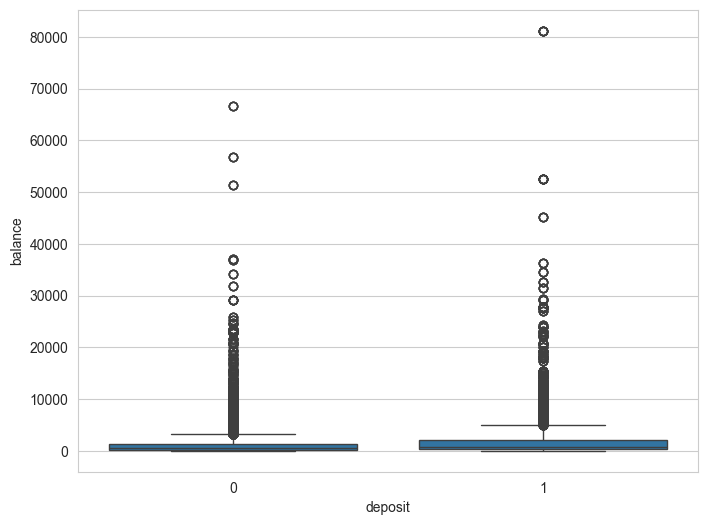

In [38]:
plt.figure(figsize=(8,6))
sns.boxplot(x="deposit",y="balance",data=data)                             
plt.show()

#### DEPOSIT VS CAMPAIGN

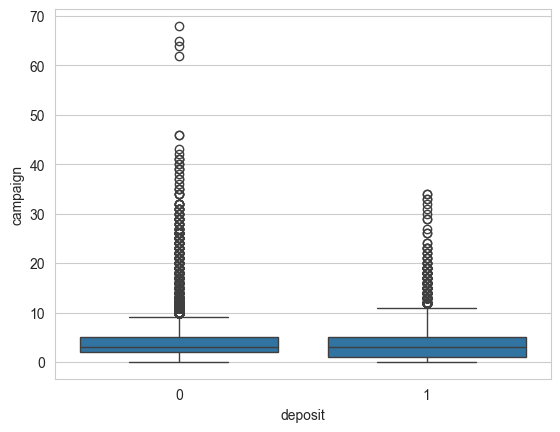

In [39]:
sns.boxplot(x="deposit",y="campaign",data=data)
plt.show()                                                                     

#### The overall box plot of the dataset

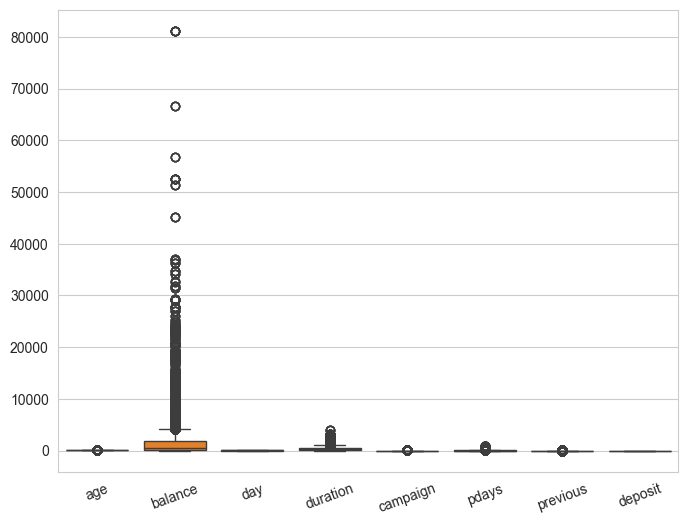

In [40]:
plt.figure(figsize=(8,6))
sns.boxplot(data=data)                                                     
plt.xticks(rotation=20)
plt.show()

In [41]:
data                                                                        

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,60.0,admin.,married,secondary,no,2348.0,yes,no,unknown,3,may,1041,4,2,0,unknown,1
1,58.0,admin.,married,secondary,no,41.0,no,no,unknown,4,may,1464,0,2,5,unknown,1
2,36.0,technician,married,secondary,no,1274.0,yes,no,unknown,10,may,1386,2,4,2,unknown,1
3,52.0,services,married,secondary,no,2477.0,yes,no,unknown,4,may,580,4,3,5,unknown,1
4,49.0,admin.,married,tertiary,no,188.0,no,no,unknown,4,may,669,2,3,3,unknown,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,49.0,technician,married,secondary,no,1835.0,yes,yes,cellular,15,aug,223,3,6,1,unknown,0
49996,50.0,unknown,married,unknown,no,552.0,no,no,telephone,24,jan,74,4,1,2,unknown,0
49997,42.0,admin.,married,secondary,no,1097.0,yes,yes,cellular,5,feb,178,4,212,6,failure,0
49998,48.0,unemployed,married,tertiary,no,1148.0,no,yes,cellular,19,nov,783,5,1,1,unknown,0


#### HEATMAP
A correlation heatmap is created using only numerical features to understand the relationships between variables such as age, balance, duration, and campaign. Categorical variables are excluded to avoid misleading correlations.

In [42]:
num_data = data.select_dtypes(include=["int64","float64"])   #remove categorical values
cor = num_data.corr()                                                 
cor

,age,balance,day,duration,campaign,pdays,previous,deposit
age,1.000000,0.100585,0.002113,-0.002882,-0.000648,0.004772,0.006497,0.032208
balance,0.100585,1.000000,0.010857,0.019878,0.001049,0.014479,0.013872,0.075454
day,0.002113,0.010857,1.000000,-0.013101,0.086328,-0.063853,-0.017250,-0.049953
duration,-0.002882,0.019878,-0.013101,1.000000,-0.028479,-0.036657,-0.014395,0.440899
campaign,-0.000648,0.001049,0.086328,-0.028479,1.000000,-0.066764,-0.008774,-0.081093
pdays,0.004772,0.014479,-0.063853,-0.036657,-0.066764,1.000000,0.208427,0.148224
previous,0.006497,0.013872,-0.017250,-0.014395,-0.008774,0.208427,1.000000,0.054163
deposit,0.032208,0.075454,-0.049953,0.440899,-0.081093,0.148224,0.054163,1.000000


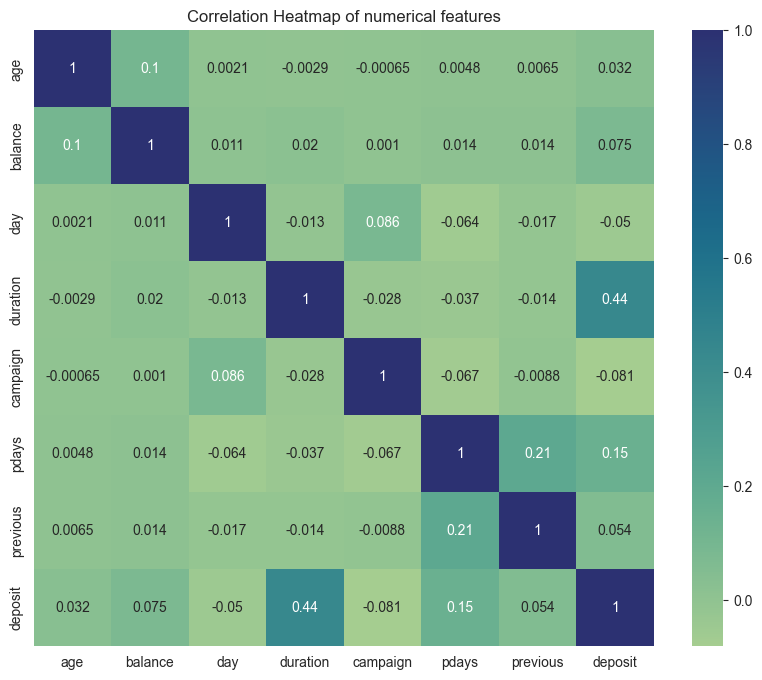

In [43]:
plt.figure(figsize=(10,8))
sns.heatmap(cor, annot=True,cmap="crest")                            
plt.title("Correlation Heatmap of numerical features")                          
plt.show()

### STEP:4 PREPROCESSING

This step includes handling missing values, converting categorical variables into numerical form, treating outliers, and removing low-impact or risky features. The objective of preprocessing is to transform the raw data into a clean and structured format suitable for machine learning.

In [44]:
data                                                                        

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,60.0,admin.,married,secondary,no,2348.0,yes,no,unknown,3,may,1041,4,2,0,unknown,1
1,58.0,admin.,married,secondary,no,41.0,no,no,unknown,4,may,1464,0,2,5,unknown,1
2,36.0,technician,married,secondary,no,1274.0,yes,no,unknown,10,may,1386,2,4,2,unknown,1
3,52.0,services,married,secondary,no,2477.0,yes,no,unknown,4,may,580,4,3,5,unknown,1
4,49.0,admin.,married,tertiary,no,188.0,no,no,unknown,4,may,669,2,3,3,unknown,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,49.0,technician,married,secondary,no,1835.0,yes,yes,cellular,15,aug,223,3,6,1,unknown,0
49996,50.0,unknown,married,unknown,no,552.0,no,no,telephone,24,jan,74,4,1,2,unknown,0
49997,42.0,admin.,married,secondary,no,1097.0,yes,yes,cellular,5,feb,178,4,212,6,failure,0
49998,48.0,unemployed,married,tertiary,no,1148.0,no,yes,cellular,19,nov,783,5,1,1,unknown,0


In [45]:
data.default.value_counts()                                                

default
no     49275
yes      725
Name: count, dtype: int64

In [46]:
data.housing.value_counts()                                                

housing
no     26918
yes    23082
Name: count, dtype: int64

In [47]:
data.loan.value_counts()                                                

loan
no     43659
yes     6341
Name: count, dtype: int64

In [48]:
data["default"] = data["default"].map({"yes": 1, "no": 0})
data["housing"] = data["housing"].map({"yes": 1, "no": 0})         
data["loan"] = data["loan"].map({"yes": 1, "no": 0})
data

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,60.0,admin.,married,secondary,0,2348.0,1,0,unknown,3,may,1041,4,2,0,unknown,1
1,58.0,admin.,married,secondary,0,41.0,0,0,unknown,4,may,1464,0,2,5,unknown,1
2,36.0,technician,married,secondary,0,1274.0,1,0,unknown,10,may,1386,2,4,2,unknown,1
3,52.0,services,married,secondary,0,2477.0,1,0,unknown,4,may,580,4,3,5,unknown,1
4,49.0,admin.,married,tertiary,0,188.0,0,0,unknown,4,may,669,2,3,3,unknown,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,49.0,technician,married,secondary,0,1835.0,1,1,cellular,15,aug,223,3,6,1,unknown,0
49996,50.0,unknown,married,unknown,0,552.0,0,0,telephone,24,jan,74,4,1,2,unknown,0
49997,42.0,admin.,married,secondary,0,1097.0,1,1,cellular,5,feb,178,4,212,6,failure,0
49998,48.0,unemployed,married,tertiary,0,1148.0,0,1,cellular,19,nov,783,5,1,1,unknown,0


In [49]:
data.dtypes                                                                 

age          float64
job           object
marital       object
education     object
default        int64
balance      float64
housing        int64
loan           int64
contact       object
day            int64
month         object
duration       int64
campaign       int64
pdays          int64
previous       int64
poutcome      object
deposit        int64
dtype: object

USING LABEL ENCODING

In [50]:
le = LabelEncoder()
data["job"]=le.fit_transform(data["job"])
li = LabelEncoder()
data["marital"]=li.fit_transform(data["marital"])
lo = LabelEncoder()
data["education"]=lo.fit_transform(data["education"])
lc = LabelEncoder()
data["contact"]=lc.fit_transform(data["contact"])
lm = LabelEncoder()
data["month"]=lm.fit_transform(data["month"])
lp = LabelEncoder()
data["poutcome"]=lp.fit_transform(data["poutcome"])
data

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,60.0,0,1,1,0,2348.0,1,0,2,3,8,1041,4,2,0,3,1
1,58.0,0,1,1,0,41.0,0,0,2,4,8,1464,0,2,5,3,1
2,36.0,9,1,1,0,1274.0,1,0,2,10,8,1386,2,4,2,3,1
3,52.0,7,1,1,0,2477.0,1,0,2,4,8,580,4,3,5,3,1
4,49.0,0,1,2,0,188.0,0,0,2,4,8,669,2,3,3,3,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,49.0,9,1,1,0,1835.0,1,1,0,15,1,223,3,6,1,3,0
49996,50.0,11,1,3,0,552.0,0,0,1,24,4,74,4,1,2,3,0
49997,42.0,0,1,1,0,1097.0,1,1,0,5,3,178,4,212,6,0,0
49998,48.0,10,1,2,0,1148.0,0,1,0,19,9,783,5,1,1,3,0


In [51]:
data.dtypes                                                            

age          float64
job            int64
marital        int64
education      int64
default        int64
balance      float64
housing        int64
loan           int64
contact        int64
day            int64
month          int64
duration       int64
campaign       int64
pdays          int64
previous       int64
poutcome       int64
deposit        int64
dtype: object

In [52]:
data.isna().sum()                                                           

age             0
job             0
marital         0
education       0
default         0
balance      2560
housing         0
loan            0
contact         0
day             0
month           0
duration        0
campaign        0
pdays           0
previous        0
poutcome        0
deposit         0
dtype: int64

In [53]:
data["balance"] = data["balance"].fillna(data["balance"].median())
data                                                                     

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,60.0,0,1,1,0,2348.0,1,0,2,3,8,1041,4,2,0,3,1
1,58.0,0,1,1,0,41.0,0,0,2,4,8,1464,0,2,5,3,1
2,36.0,9,1,1,0,1274.0,1,0,2,10,8,1386,2,4,2,3,1
3,52.0,7,1,1,0,2477.0,1,0,2,4,8,580,4,3,5,3,1
4,49.0,0,1,2,0,188.0,0,0,2,4,8,669,2,3,3,3,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,49.0,9,1,1,0,1835.0,1,1,0,15,1,223,3,6,1,3,0
49996,50.0,11,1,3,0,552.0,0,0,1,24,4,74,4,1,2,3,0
49997,42.0,0,1,1,0,1097.0,1,1,0,5,3,178,4,212,6,0,0
49998,48.0,10,1,2,0,1148.0,0,1,0,19,9,783,5,1,1,3,0


In [54]:
data.isna().sum()
data.dtypes                                                             

age          float64
job            int64
marital        int64
education      int64
default        int64
balance      float64
housing        int64
loan           int64
contact        int64
day            int64
month          int64
duration       int64
campaign       int64
pdays          int64
previous       int64
poutcome       int64
deposit        int64
dtype: object

#### IQR method for outlier treatment

In [55]:
Q1 = data["balance"].quantile(0.25)
Q3 = data["balance"].quantile(0.75)
IQR = Q3 - Q1                                                           

In [56]:
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR                                                     

In [57]:
data["balance"] = data["balance"].clip(lower, upper)           #clip function value nne range ll kittan lower and upper range ll                      

In [58]:
data                                                                    

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,60.0,0,1,1,0,2348.0,1,0,2,3,8,1041,4,2,0,3,1
1,58.0,0,1,1,0,41.0,0,0,2,4,8,1464,0,2,5,3,1
2,36.0,9,1,1,0,1274.0,1,0,2,10,8,1386,2,4,2,3,1
3,52.0,7,1,1,0,2477.0,1,0,2,4,8,580,4,3,5,3,1
4,49.0,0,1,2,0,188.0,0,0,2,4,8,669,2,3,3,3,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,49.0,9,1,1,0,1835.0,1,1,0,15,1,223,3,6,1,3,0
49996,50.0,11,1,3,0,552.0,0,0,1,24,4,74,4,1,2,3,0
49997,42.0,0,1,1,0,1097.0,1,1,0,5,3,178,4,212,6,0,0
49998,48.0,10,1,2,0,1148.0,0,1,0,19,9,783,5,1,1,3,0


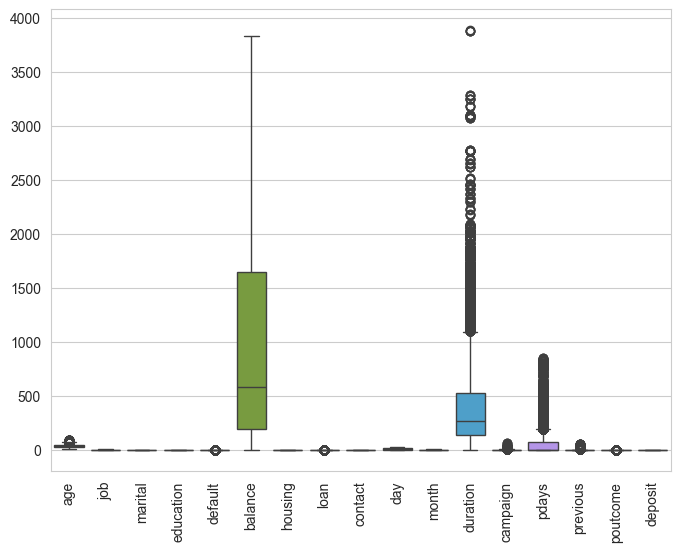

In [59]:
plt.figure(figsize=(8,6))
sns.boxplot(data=data)
plt.xticks(rotation=90)                                                
plt.show()

#### The duration column is removed because it is only known after the call ends and causes data leakage in prediction.

In [60]:
data = data.drop(columns=["duration"])  # Dropping duration to avoid data leakage
data                                                                  

,age,job,marital,education,default,balance,housing,loan,contact,day,month,campaign,pdays,previous,poutcome,deposit
0,60.0,0,1,1,0,2348.0,1,0,2,3,8,4,2,0,3,1
1,58.0,0,1,1,0,41.0,0,0,2,4,8,0,2,5,3,1
2,36.0,9,1,1,0,1274.0,1,0,2,10,8,2,4,2,3,1
3,52.0,7,1,1,0,2477.0,1,0,2,4,8,4,3,5,3,1
4,49.0,0,1,2,0,188.0,0,0,2,4,8,2,3,3,3,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,49.0,9,1,1,0,1835.0,1,1,0,15,1,3,6,1,3,0
49996,50.0,11,1,3,0,552.0,0,0,1,24,4,4,1,2,3,0
49997,42.0,0,1,1,0,1097.0,1,1,0,5,3,4,212,6,0,0
49998,48.0,10,1,2,0,1148.0,0,1,0,19,9,5,1,1,3,0


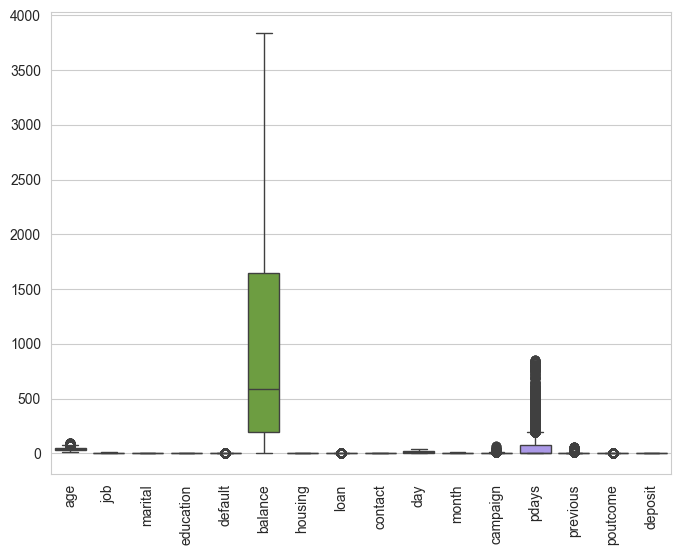

In [61]:
plt.figure(figsize=(8,6))
sns.boxplot(data=data)
plt.xticks(rotation=90)                                                   
plt.show()                                                              

In [62]:
cor = data.corr().T                                                      
cor

,age,job,marital,education,default,balance,housing,loan,contact,day,month,campaign,pdays,previous,poutcome,deposit
age,1.000000,-0.024126,-0.415726,-0.113255,-0.009042,0.123565,-0.153751,-0.033275,0.024836,0.002113,-0.025261,-0.000648,0.004772,0.006497,-0.003935,0.032208
job,-0.024126,1.000000,0.075167,0.133763,-0.007644,0.032921,-0.132605,-0.064665,-0.086811,0.023238,-0.070632,-0.004062,-0.000865,0.005384,-0.004706,0.062544
marital,-0.415726,0.075167,1.000000,0.120845,-0.014335,-0.010340,-0.037684,-0.056822,-0.062160,-0.002102,-0.004823,-0.018212,0.029022,0.011912,-0.037617,0.067519
education,-0.113255,0.133763,0.120845,1.000000,-0.009770,0.058254,-0.104290,-0.069219,-0.128793,0.014522,-0.051654,-0.010646,0.024770,0.000627,-0.041512,0.092405
default,-0.009042,-0.007644,-0.014335,-0.009770,1.000000,-0.075292,0.016885,0.076449,0.037318,0.016075,0.000118,0.015942,-0.035755,-0.016082,0.042481,-0.041378
balance,0.123565,0.032921,-0.010340,0.058254,-0.075292,1.000000,-0.081758,-0.102720,-0.038500,0.012460,0.030039,-0.021564,0.024909,0.022247,-0.045023,0.126198
housing,-0.153751,-0.132605,-0.037684,-0.104290,0.016885,-0.081758,1.000000,0.082310,0.222427,-0.009397,0.201900,0.009404,0.054558,0.004099,-0.034463,-0.204148
loan,-0.033275,-0.064665,-0.056822,-0.069219,0.076449,-0.102720,0.082310,1.000000,0.014335,0.014246,0.026835,0.022484,-0.032579,-0.007765,0.029488,-0.112789
contact,0.024836,-0.086811,-0.062160,-0.128793,0.037318,-0.038500,0.222427,0.014335,1.000000,0.008135,0.278744,0.050296,-0.222585,-0.061398,0.253746,-0.254392
day,0.002113,0.023238,-0.002102,0.014522,0.016075,0.012460,-0.009397,0.014246,0.008135,1.000000,-0.020898,0.086328,-0.063853,-0.017250,0.066944,-0.049953


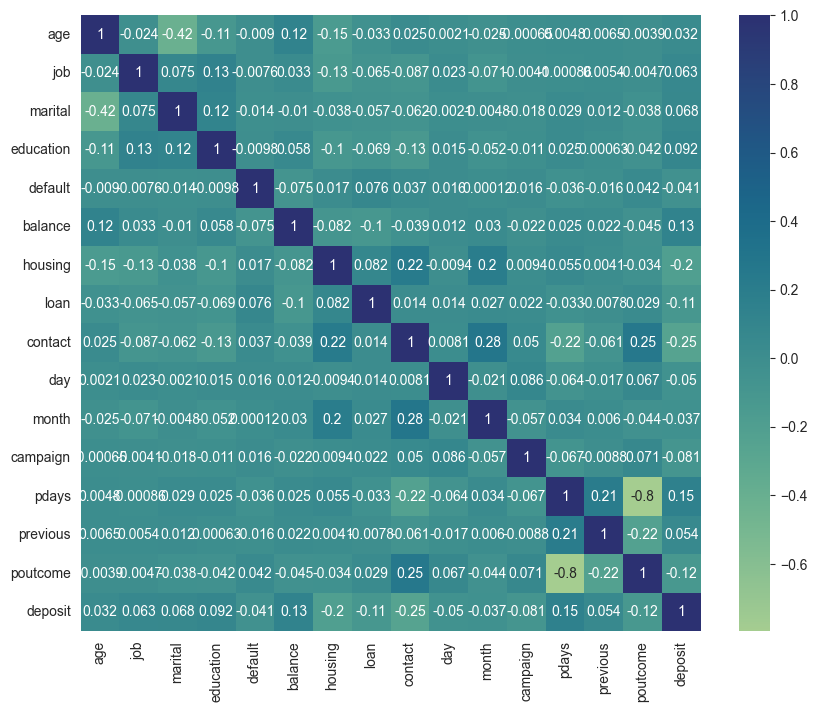

In [63]:
plt.figure(figsize=(10,8))
sns.heatmap(cor,annot=True,cmap="crest")                                   
plt.show()

### STEP 5: Training the Machine Learning Model

#### SPLITTING DATASET

In [64]:
data                                                                      

,age,job,marital,education,default,balance,housing,loan,contact,day,month,campaign,pdays,previous,poutcome,deposit
0,60.0,0,1,1,0,2348.0,1,0,2,3,8,4,2,0,3,1
1,58.0,0,1,1,0,41.0,0,0,2,4,8,0,2,5,3,1
2,36.0,9,1,1,0,1274.0,1,0,2,10,8,2,4,2,3,1
3,52.0,7,1,1,0,2477.0,1,0,2,4,8,4,3,5,3,1
4,49.0,0,1,2,0,188.0,0,0,2,4,8,2,3,3,3,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,49.0,9,1,1,0,1835.0,1,1,0,15,1,3,6,1,3,0
49996,50.0,11,1,3,0,552.0,0,0,1,24,4,4,1,2,3,0
49997,42.0,0,1,1,0,1097.0,1,1,0,5,3,4,212,6,0,0
49998,48.0,10,1,2,0,1148.0,0,1,0,19,9,5,1,1,3,0


In [65]:
x = data.drop("deposit",axis=1)
y = data["deposit"]

In [66]:
print("\nX_Dataset\n",x)
print("\nY_Data\n",y)                                                    


X_Dataset
         age  job  marital  education  default  balance  housing  loan  \
0      60.0    0        1          1        0   2348.0        1     0   
1      58.0    0        1          1        0     41.0        0     0   
2      36.0    9        1          1        0   1274.0        1     0   
3      52.0    7        1          1        0   2477.0        1     0   
4      49.0    0        1          2        0    188.0        0     0   
...     ...  ...      ...        ...      ...      ...      ...   ...   
49995  49.0    9        1          1        0   1835.0        1     1   
49996  50.0   11        1          3        0    552.0        0     0   
49997  42.0    0        1          1        0   1097.0        1     1   
49998  48.0   10        1          2        0   1148.0        0     1   
49999  35.0    9        2          2        0   3815.0        0     0   

       contact  day  month  campaign  pdays  previous  poutcome  
0            2    3      8         4      2  

In [67]:
x_train,x_test,y_train,y_test = train_test_split(x,y, test_size=0.30, random_state=42)

#### USING MIN MAX SCALER

In [68]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
x_train_scaler = scaler.fit_transform(x_train)                              
x_test_scaler = scaler.transform(x_test) 

### LogisticRegression

In [69]:
log = LogisticRegression()
log.fit(x_train_scaler,y_train)
y_pred_test = log.predict(x_test_scaler)
y_pred_train = log.predict(x_train_scaler)                                

In [70]:
log_train = log.score(x_train_scaler, y_train)
log_test  = log.score(x_test_scaler, y_test)
print("training score :", log_train)
print("testing score  :", log_test)
cm =confusion_matrix(y_test,y_pred_test)
print("\nconfusion_matrix\n",cm)
print("\nclassification_report\n",classification_report(y_test,y_pred_test)) 

training score : 0.6539714285714285
testing score  : 0.6576

confusion_matrix
 [[3908 3246]
 [1890 5956]]

classification_report
               precision    recall  f1-score   support

           0       0.67      0.55      0.60      7154
           1       0.65      0.76      0.70      7846

    accuracy                           0.66     15000
   macro avg       0.66      0.65      0.65     15000
weighted avg       0.66      0.66      0.65     15000



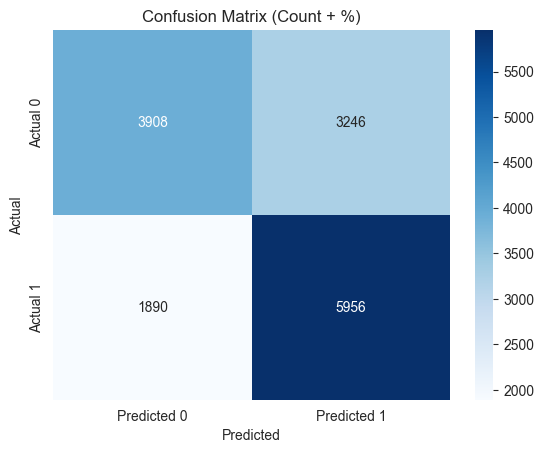

In [71]:
sns.heatmap( cm,annot=True,fmt="d",cmap="Blues",xticklabels=["Predicted 0", "Predicted 1"],yticklabels=["Actual 0", "Actual 1"])
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.title("Confusion Matrix (Count + %)")                                 
plt.show() 

In [72]:
log_score = accuracy_score(y_test,y_pred_test)*100
print("accuracy_score :",log_score)                                         

accuracy_score : 65.75999999999999


### Decision Tree

In [73]:
tree = DecisionTreeClassifier(max_depth=9,random_state=42)
tree.fit(x_train,y_train)                                                  
y_pred_test = tree.predict(x_test)
x_pred_train = tree.predict(x_train)                                           

In [74]:
tree_train = tree.score(x_train, y_train)                                         
tree_test  = tree.score(x_test, y_test)

print("training score :", tree_train)
print("testing score  :", tree_test)
cm = confusion_matrix(y_test,y_pred_test)
print("\nconfusion_matrix :\n",cm)
print(classification_report(y_test,y_pred_test))

training score : 0.7214857142857143
testing score  : 0.7119333333333333

confusion_matrix :
 [[5561 1593]
 [2728 5118]]
              precision    recall  f1-score   support

           0       0.67      0.78      0.72      7154
           1       0.76      0.65      0.70      7846

    accuracy                           0.71     15000
   macro avg       0.72      0.71      0.71     15000
weighted avg       0.72      0.71      0.71     15000



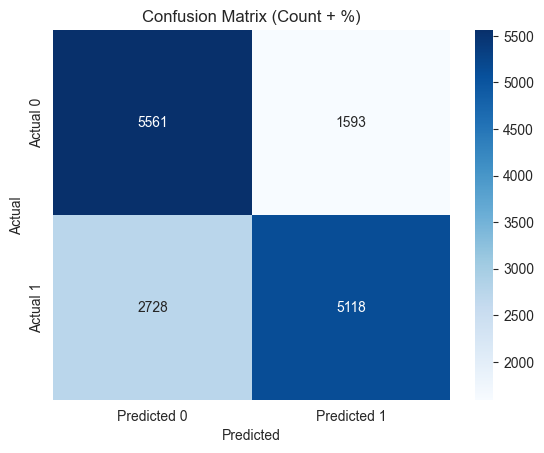

In [75]:
sns.heatmap( cm,annot=True,fmt="d",cmap="Blues",xticklabels=["Predicted 0", "Predicted 1"],yticklabels=["Actual 0", "Actual 1"])
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.title("Confusion Matrix (Count + %)")                                      
plt.show()

In [76]:
tree_score = accuracy_score(y_test,y_pred_test)*100
print("accuracy_score :",tree_score)                                        

accuracy_score : 71.19333333333333


### RANDOM FOREST

In [77]:
ran = RandomForestClassifier(n_estimators=400,max_depth=10,random_state=42,min_samples_split=10) 
ran.fit(x_train,y_train) 
y_pred_test = ran.predict(x_test) 
y_pred_train = ran.predict(x_train)                                       

In [78]:
rf_train = ran.score(x_train, y_train) 
rf_test  = ran.score(x_test, y_test) 

print("training score :", rf_train) 
print("testing score  :", rf_test) 
cm = confusion_matrix(y_test,y_pred_test) 
print("\nConfusion Matrix :\n",cm) 
print("\nClassification Report :\n",classification_report(y_test,y_pred_test)) 

training score : 0.7470285714285714
testing score  : 0.7266

Confusion Matrix :
 [[5277 1877]
 [2224 5622]]

Classification Report :
               precision    recall  f1-score   support

           0       0.70      0.74      0.72      7154
           1       0.75      0.72      0.73      7846

    accuracy                           0.73     15000
   macro avg       0.73      0.73      0.73     15000
weighted avg       0.73      0.73      0.73     15000



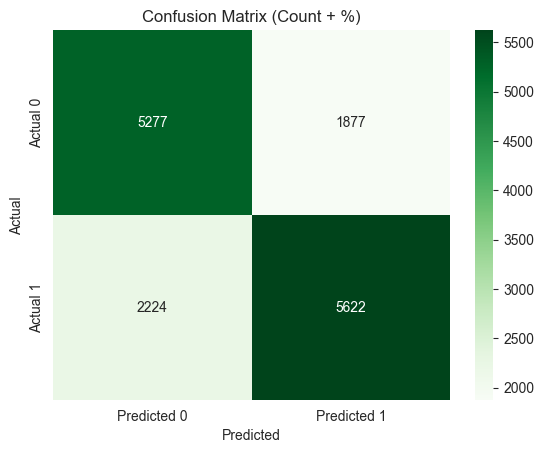

In [79]:
sns.heatmap(cm,annot=True,fmt="d",cmap="Greens",xticklabels=["Predicted 0", "Predicted 1"],yticklabels=["Actual 0", "Actual 1"]) 
plt.ylabel("Actual") 
plt.xlabel("Predicted")
plt.title("Confusion Matrix (Count + %)")                                                                     
plt.show() 

In [80]:
ran_score = accuracy_score(y_test,y_pred_test)*100 
print("Accuracy Score :",ran_score)                                                               

Accuracy Score : 72.66


### K NEAREST NEIGHBORS(KNN)

In [81]:
knn = KNeighborsClassifier(n_neighbors=9)                                    
knn.fit(x_train_scaler,y_train) 
y_pred_test = knn.predict(x_test_scaler) 
y_pred_train = knn.predict(x_train_scaler)  

In [82]:
knn_train = knn.score(x_train_scaler, y_train) 
knn_test  = knn.score(x_test_scaler, y_test) 

print("training score :", knn_train)
print("testing score  :", knn_test)
cm = confusion_matrix(y_test,y_pred_test)                                          
print("\nConfusion_Matrix :\n",cm)
print("\nClassification_Report :\n",classification_report(y_test,y_pred_test)) 

training score : 0.8098285714285715
testing score  : 0.7424666666666667

Confusion_Matrix :
 [[5299 1855]
 [2008 5838]]

Classification_Report :
               precision    recall  f1-score   support

           0       0.73      0.74      0.73      7154
           1       0.76      0.74      0.75      7846

    accuracy                           0.74     15000
   macro avg       0.74      0.74      0.74     15000
weighted avg       0.74      0.74      0.74     15000



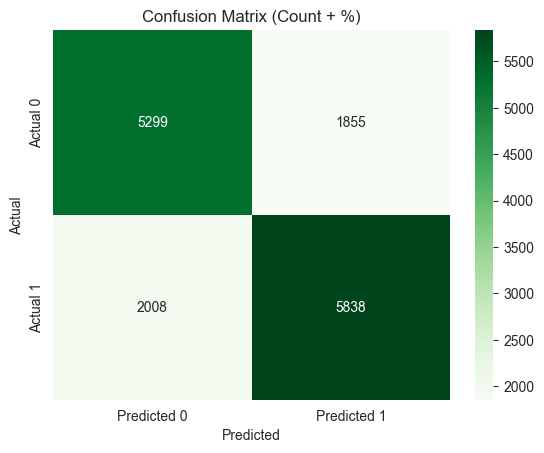

In [83]:
sns.heatmap(cm,annot=True,fmt="d",cmap="Greens",xticklabels=["Predicted 0", "Predicted 1"],yticklabels=["Actual 0", "Actual 1"]) 
plt.ylabel("Actual") 
plt.xlabel("Predicted")                                                
plt.title("Confusion Matrix (Count + %)")
plt.show()

In [84]:
knn_score = accuracy_score(y_test,y_pred_test)*100                              
print("Accuracy Score :",knn_score)

Accuracy Score : 74.24666666666667


### NAIVE BAYES (GAUSSIAN NB)

In [85]:
nb = GaussianNB()
nb.fit(x_train_scaler,y_train) 
y_pred_test = nb.predict(x_test_scaler)
y_pred_train = nb.predict(x_train_scaler)

In [86]:
nb_train = nb.score(x_train_scaler, y_train)
nb_test = nb.score(x_test_scaler, y_test)
                                                                          
print("training score :", nb_train)
print("testing score  :", nb_test)
cm = confusion_matrix(y_test,y_pred_test) 
print("\nConfusion Matrix",cm)
print(classification_report(y_test,y_pred_test)) 

training score : 0.6554857142857143
testing score  : 0.6578666666666667

Confusion Matrix [[3741 3413]
 [1719 6127]]
              precision    recall  f1-score   support

           0       0.69      0.52      0.59      7154
           1       0.64      0.78      0.70      7846

    accuracy                           0.66     15000
   macro avg       0.66      0.65      0.65     15000
weighted avg       0.66      0.66      0.65     15000



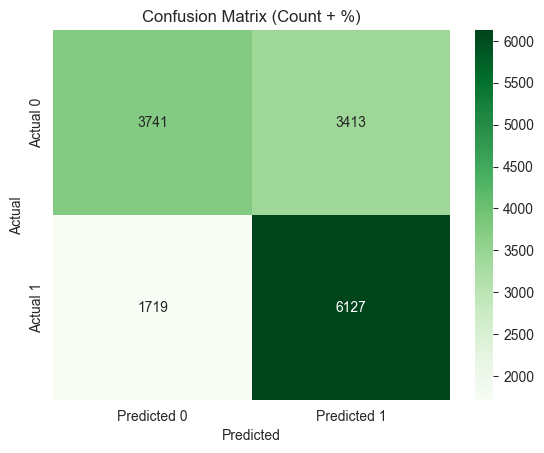

In [87]:
sns.heatmap(cm,annot=True,fmt="d",cmap="Greens",xticklabels=["Predicted 0", "Predicted 1"],yticklabels=["Actual 0", "Actual 1"])
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.title("Confusion Matrix (Count + %)")                                       
plt.show() 

In [88]:
nb_score = accuracy_score(y_test,y_pred_test)*100 
print("Accuracy Score :",nb_score)                                                  

Accuracy Score : 65.78666666666668


### SUPPORT VECTOR MACHINE (SVM)

In [89]:
svm = SVC(kernel="linear") 
svm.fit(x_train_scaler,y_train) 
y_pred_test = svm.predict(x_test_scaler) 
y_pred_train = svm.predict(x_train_scaler)                                              

In [90]:
svm1=svm.score(x_test_scaler,y_test)
svm1                                                                           

0.6442666666666667

In [91]:
svm2=svm.score(x_train_scaler,y_train)
svm2                                                                                                                           

0.6431714285714286

In [92]:
cm = confusion_matrix(y_test,y_pred_test)
print("\nConfusion Matrix :\n",cm)
print("\nClassification Report: \n",classification_report(y_test,y_pred_test))


Confusion Matrix :
 [[3253 3901]
 [1435 6411]]

Classification Report: 
               precision    recall  f1-score   support

           0       0.69      0.45      0.55      7154
           1       0.62      0.82      0.71      7846

    accuracy                           0.64     15000
   macro avg       0.66      0.64      0.63     15000
weighted avg       0.66      0.64      0.63     15000



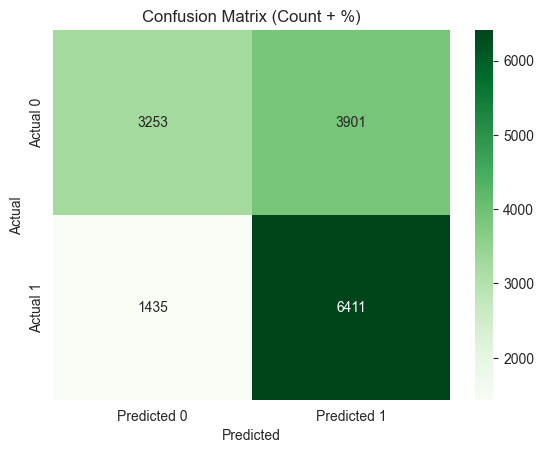

In [93]:
sns.heatmap(cm,annot=True,fmt="d",cmap="Greens",xticklabels=["Predicted 0", "Predicted 1"],yticklabels=["Actual 0", "Actual 1"])
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.title("Confusion Matrix (Count + %)")
plt.show()

In [94]:
svm_score = accuracy_score(y_test,y_pred_test)*100
print("Accuracy Score :",svm_score)

Accuracy Score : 64.42666666666666


### ENSEMBLE TECHNIQUE

In this project, boosting algorithms such as AdaBoost, Gradient Boosting, and XGBoost were used to improve classification performance. These methods work by training models sequentially, where each new model focuses on correcting the mistakes made by previous models. As a result, boosting techniques provided higher accuracy and better learning of complex patterns compared to single models.

### ADABOOST

In [95]:
base_estimator = DecisionTreeClassifier(random_state=42,max_depth=3)
ada = AdaBoostClassifier(n_estimators=400,random_state=42,estimator=base_estimator)
ada.fit(x_train,y_train) 
y_pred_test = ada.predict(x_test)
y_pred_train = ada.predict(x_train)

In [96]:
ada_train = ada.score(x_train, y_train)
ada_test  = ada.score(x_test, y_test)

print("training score :", ada_train)
print("testing score  :", ada_test)
cm = confusion_matrix(y_test,y_pred_test)
print("\nConfusion Matrix :\n",cm) 
print("\nClassification Report :\n",classification_report(y_test,y_pred_test)) 

training score : 0.7193714285714286
testing score  : 0.7174666666666667

Confusion Matrix :
 [[5209 1945]
 [2293 5553]]

Classification Report :
               precision    recall  f1-score   support

           0       0.69      0.73      0.71      7154
           1       0.74      0.71      0.72      7846

    accuracy                           0.72     15000
   macro avg       0.72      0.72      0.72     15000
weighted avg       0.72      0.72      0.72     15000



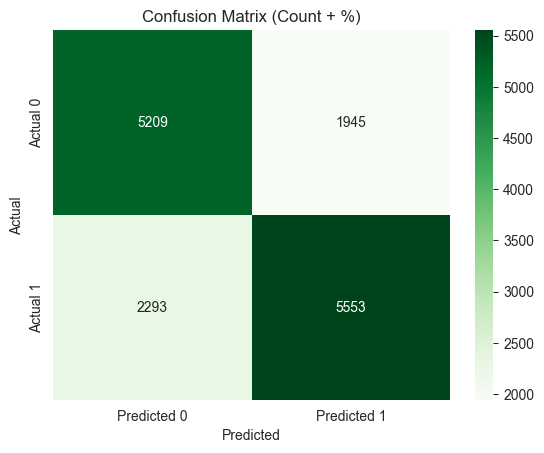

In [97]:
sns.heatmap(cm,annot=True,fmt="d",cmap="Greens",xticklabels=["Predicted 0", "Predicted 1"],yticklabels=["Actual 0", "Actual 1"])
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.title("Confusion Matrix (Count + %)")
plt.show()

In [98]:
ada_score = accuracy_score(y_test,y_pred_test)*100
print("Accuracy Score",ada_score)

Accuracy Score 71.74666666666667


### GRADIENT BOOSTING

In [99]:
gb = GradientBoostingClassifier(n_estimators=400,random_state=42)
gb.fit(x_train,y_train)
y_pred_test = gb.predict(x_test)
y_pred_train = gb.predict(x_train)

In [100]:
train_score = gb.score(x_train, y_train)
test_score  = gb.score(x_test, y_test)

print("training score :", train_score)
print("testing score  :", test_score)
cm = confusion_matrix(y_test,y_pred_test)
print("\nConfusion Matrix\n",cm)
print("\nClassification Report\n",classification_report(y_test,y_pred_test))

training score : 0.7532857142857143
testing score  : 0.7412666666666666

Confusion Matrix
 [[5598 1556]
 [2325 5521]]

Classification Report
               precision    recall  f1-score   support

           0       0.71      0.78      0.74      7154
           1       0.78      0.70      0.74      7846

    accuracy                           0.74     15000
   macro avg       0.74      0.74      0.74     15000
weighted avg       0.75      0.74      0.74     15000



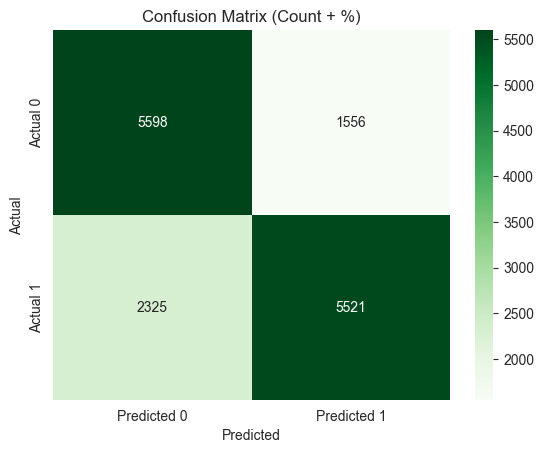

In [101]:
sns.heatmap(cm,annot=True,fmt="d",cmap="Greens",xticklabels=["Predicted 0", "Predicted 1"],yticklabels=["Actual 0", "Actual 1"])
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.title("Confusion Matrix (Count + %)")                                 
plt.show()

In [102]:
gb_score = accuracy_score(y_test,y_pred_test)*100
print("Accuracy Score :",gb_score)                                         

Accuracy Score : 74.12666666666667


### XGBOOST

In [103]:
xgb = XGBClassifier(n_estimators=500,max_depth=8,learning_rate=0.05,random_state=42)
xgb.fit(x_train,y_train)                                                
y_pred_test = xgb.predict(x_test)
y_pred_train = xgb.predict(x_train)

In [104]:
xgb_train = xgb.score(x_train, y_train)
xgb_test  = xgb.score(x_test, y_test)                                           

print("training score :", xgb_train)                                       
print("testing score  :", xgb_test)                                           
cm = confusion_matrix(y_test,y_pred_test)
print("\nConfusion Matrix :\n",cm)
print("\nClassification_Report :\n",classification_report(y_test,y_pred_test))

training score : 0.9052
testing score  : 0.8000666666666667

Confusion Matrix :
 [[5871 1283]
 [1716 6130]]

Classification_Report :
               precision    recall  f1-score   support

           0       0.77      0.82      0.80      7154
           1       0.83      0.78      0.80      7846

    accuracy                           0.80     15000
   macro avg       0.80      0.80      0.80     15000
weighted avg       0.80      0.80      0.80     15000



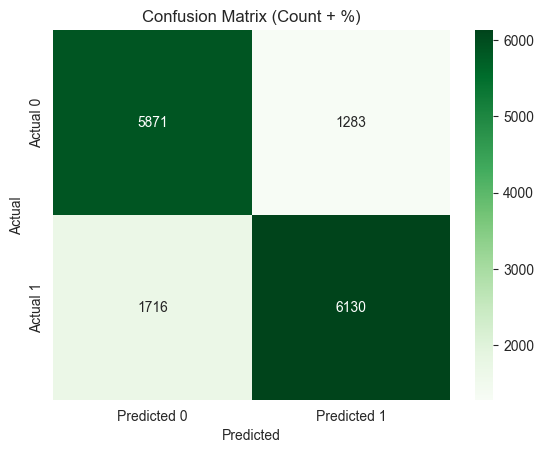

In [105]:
sns.heatmap(cm,annot=True,fmt="d",cmap="Greens",xticklabels=["Predicted 0", "Predicted 1"],yticklabels=["Actual 0", "Actual 1"])
plt.ylabel("Actual")
plt.xlabel("Predicted")                                                    
plt.title("Confusion Matrix (Count + %)")
plt.show()

In [106]:
xgb_score = accuracy_score(y_test,y_pred_test)*100
print("Accuracy Score :",xgb_score)                                             

Accuracy Score : 80.00666666666667


### MODEL AND SCORE

In [107]:
tb=pd.DataFrame()
tb['model']=pd.Series(['log','tree','rf','knn','nb','svm','ab','gb','xgb'])
tb["testing"]=pd.Series([log_test,tree_test,rf_test,knn_test,nb_test,svm1,ada_test,test_score,xgb_test])
tb["training"]=pd.Series([log_train,tree_train,rf_train,knn_train,nb_train,svm2,ada_train,train_score,xgb_train])
tb['accuracy']=pd.Series([log_score,tree_score,ran_score,knn_score,nb_score,svm_score,ada_score,gb_score,xgb_score])
tb

,model,testing,training,accuracy
0,log,0.657600,0.653971,65.760000
1,tree,0.711933,0.721486,71.193333
2,rf,0.726600,0.747029,72.660000
3,knn,0.742467,0.809829,74.246667
4,nb,0.657867,0.655486,65.786667
5,svm,0.644267,0.643171,64.426667
6,ab,0.717467,0.719371,71.746667
7,gb,0.741267,0.753286,74.126667
8,xgb,0.800067,0.905200,80.006667


### CROSS VALIDATION
Cross validation is a technique used to check how well a model performs on different subsets of data, instead of relying on just one train-test split.

In [108]:
data

,age,job,marital,education,default,balance,housing,loan,contact,day,month,campaign,pdays,previous,poutcome,deposit
0,60.0,0,1,1,0,2348.0,1,0,2,3,8,4,2,0,3,1
1,58.0,0,1,1,0,41.0,0,0,2,4,8,0,2,5,3,1
2,36.0,9,1,1,0,1274.0,1,0,2,10,8,2,4,2,3,1
3,52.0,7,1,1,0,2477.0,1,0,2,4,8,4,3,5,3,1
4,49.0,0,1,2,0,188.0,0,0,2,4,8,2,3,3,3,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,49.0,9,1,1,0,1835.0,1,1,0,15,1,3,6,1,3,0
49996,50.0,11,1,3,0,552.0,0,0,1,24,4,4,1,2,3,0
49997,42.0,0,1,1,0,1097.0,1,1,0,5,3,4,212,6,0,0
49998,48.0,10,1,2,0,1148.0,0,1,0,19,9,5,1,1,3,0


In [109]:
from sklearn.model_selection import KFold,StratifiedKFold
from sklearn.model_selection import cross_val_score
x = data.drop("deposit",axis=1)                     
y = data["deposit"]

#### StratifiedKFold

StratifiedKFold is similar to KFold, but it ensures that each fold maintains the same class distribution as the original dataset. This method is mainly used for classification problems to get reliable and unbiased results

In [110]:
skf = StratifiedKFold(n_splits=6,random_state=42,shuffle=True)    #shuffle = Data order bias avoid cheyyan.
log_score = []
tree_score = []
forest_score = [] 
knn_score = []
naive_score = []
svm_score = []
ada_score = []
gb_score = []
xgb_score = []

log_score = cross_val_score(LogisticRegression(),x,y,cv=skf) 
tree_score = cross_val_score(DecisionTreeClassifier(max_depth=7),x,y,cv=skf)                                    
forest_score = cross_val_score(RandomForestClassifier(n_estimators=200,max_depth=10,random_state=42),x,y,cv=skf)
knn_score = cross_val_score(KNeighborsClassifier(),x,y,cv=skf) 
naive_score = cross_val_score(GaussianNB(),x,y,cv=skf)
svm_score = cross_val_score(SVC(),x,y,cv=skf) 
ada_score = cross_val_score(AdaBoostClassifier(n_estimators=200,random_state=42),x,y,cv=skf) 
gb_score = cross_val_score(GradientBoostingClassifier(n_estimators=200,max_depth=3,random_state=42),x,y,cv=skf) 
xgb_score = cross_val_score(XGBClassifier(n_estimators=300,random_state=42,max_depth=4),x,y,cv=skf)

log_mean = log_score.mean()
tree_mean = tree_score.mean()
forest_mean = forest_score.mean()
knn_mean = knn_score.mean()
naive_mean = naive_score.mean()
svm_mean = svm_score.mean()
ada_mean = ada_score.mean()
gb_mean = gb_score.mean()
xgb_mean = xgb_score.mean() 

print("LogisticRegression Score :",log_mean)
print("Decision Tree Classifier Score :",tree_mean) 
print("Random Forest Classifier Score :",forest_mean)
print("KNN Score :",knn_mean)
print("Naive Bayes Score:",naive_mean)
print("SVC Score :",svm_mean)
print("AdaBoostClassifier Score :",ada_mean)
print("GradientBoostClassifier Score :",gb_mean)
print("XGB Score :",xgb_mean) 

LogisticRegression Score : 0.6482400620718852
Decision Tree Classifier Score : 0.6900599758091596
Random Forest Classifier Score : 0.7283399567324186
KNN Score : 0.7495200767953923
Naive Bayes Score: 0.6563800972965245
SVC Score : 0.5859800722722454
AdaBoostClassifier Score : 0.7007801094381189
GradientBoostClassifier Score : 0.7284399679322906
XGB Score : 0.7671999824557417


#### KFold

KFold cross-validation splits the dataset into K equal parts. The model is trained on K−1 parts and tested on the remaining part. This process is repeated K times, and the average score is taken as the final result.

In [111]:
sk = KFold(n_splits=6,random_state=42,shuffle=True)    
log_score = []
tree_score = []
forest_score = []
knn_score = []
naive_score = []
svm_score = []
ada_score = [] 
gb_score = []
xgb_score = []

log_score = cross_val_score(LogisticRegression(),x,y,cv=sk)
tree_score = cross_val_score(DecisionTreeClassifier(max_depth=7),x,y,cv=sk)
forest_score = cross_val_score(RandomForestClassifier(n_estimators=200,max_depth=10,random_state=42),x,y,cv=sk)
knn_score = cross_val_score(KNeighborsClassifier(),x,y,cv=sk)
naive_score = cross_val_score(GaussianNB(),x,y,cv=sk)
svm_score = cross_val_score(SVC(),x,y,cv=sk)
ada_score = cross_val_score(AdaBoostClassifier(n_estimators=200,random_state=42),x,y,cv=sk)
gb_score = cross_val_score(GradientBoostingClassifier(n_estimators=200,max_depth=3,random_state=42),x,y,cv=sk)
xgb_score = cross_val_score(XGBClassifier(n_estimators=300,random_state=42,max_depth=4),x,y,cv=sk)

log_mean1 = log_score.mean()
tree_mean1 = tree_score.mean()
forest_mean1 = forest_score.mean()
knn_mean1 = knn_score.mean()
naive_mean1 = naive_score.mean()
svm_mean1 = svm_score.mean()
ada_mean1 = ada_score.mean()
gb_mean1 = gb_score.mean()
xgb_mean1 = xgb_score.mean()

print("LogisticRegression Score :",log_mean1)
print("Decision Tree Classifier Score :",tree_mean1) 
print("Random Forest Classifier Score :",forest_mean1)
print("KNN Score :",knn_mean1)
print("Naive Bayes Score:",naive_mean1)
print("SVC Score :",svm_mean1)
print("AdaBoostClassifier Score :",ada_mean1)
print("GradientBoostClassifier Score :",gb_mean1)
print("XGB Score :",xgb_mean1) 

LogisticRegression Score : 0.6489400420749252
Decision Tree Classifier Score : 0.6917599406160071
Random Forest Classifier Score : 0.7296399895352667
KNN Score : 0.7497000671963523
Naive Bayes Score: 0.6569999829030838
SVC Score : 0.5860399546771408
AdaBoostClassifier Score : 0.7007400286412224
GradientBoostClassifier Score : 0.7298998199428817
XGB Score : 0.7661600128511981


In [112]:
score = pd.DataFrame()
score["Model"]=pd.Series(["LogisticRegression","DecisionTree","RandomForest","KNN","NaiveBayes","svm","AdaaBoost","GradientBoosting","XGBoost"])
score["KFold_Score"] =pd.Series([log_mean1,tree_mean1,forest_mean1,knn_mean1,naive_mean1,svm_mean1,ada_mean1,gb_mean1,xgb_mean1])
score["Stratified_KFold"]=pd.Series([log_mean,tree_mean,forest_mean,knn_mean,naive_mean,svm_mean,ada_mean,gb_mean,xgb_mean])
score

,Model,KFold_Score,Stratified_KFold
0,LogisticRegression,0.64894,0.64824
1,DecisionTree,0.69176,0.69006
2,RandomForest,0.72964,0.72834
3,KNN,0.74970,0.74952
4,NaiveBayes,0.65700,0.65638
5,svm,0.58604,0.58598
6,AdaaBoost,0.70074,0.70078
7,GradientBoosting,0.72990,0.72844
8,XGBoost,0.76616,0.76720


### HYPERTUNING

In [113]:
xgb_param = {
    "n_estimators": [400, 500],     
    "max_depth": [7, 9],
    "learning_rate": [0.03, 0.05],
    "subsample": [0.8, 0.9], #% use cheyunu data nte 
    "colsample_bytree": [0.8], # oro split nte feature etra venm
    "gamma": [0, 0.1], #split cheyan 
    "reg_alpha": [0, 0.01], # leaf 0 akki overfitting kurakunu 
    "reg_lambda": [1, 1.5] # leaf simple akie over fitting kurakunu 
}
xgb = XGBClassifier(eval_metric="logloss",random_state=42,tree_method="hist",n_jobs=-1)

grid = GridSearchCV(estimator=xgb,param_grid=xgb_param,scoring="accuracy",verbose=1,cv=3) 
grid.fit(x_train, y_train)

best_model = grid.best_estimator_
print("Best Parameters:", best_model) 
best_score = grid.best_score_
print("Best Score:",best_score) 
best_params = grid.best_params_
print("Best Params:",best_params)   

Fitting 3 folds for each of 128 candidates, totalling 384 fits
Best Parameters: XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=0, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=9,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=500,
              n_jobs=-1, num_parallel_tree=None, random_state=42, ...)
Best Score: 0.792885509043745
Best Params: {'colsample_bytree': 0.8, 'gamma': 0, 'learning_rate': 0.05, 'max_depth': 9, 'n_estimators': 500, 'reg_alpha': 0.01, 'reg_lamb

### Final Step:- Fit the final model

In [114]:
y_pred = grid.predict(x_test)
y_pred

array([0, 0, 1, ..., 1, 0, 1])

In [115]:
test_score = grid.score(x_test,y_test)
train_score = grid.score(x_train,y_train)
print("Testing Score :",test_score)
print("Training Score :",train_score)
cm = confusion_matrix(y_test,y_pred)
print("\nConfusion Matrix :\n",cm) 
print("\nClassification Report\n",classification_report(y_test,y_pred))

Testing Score : 0.8206
Training Score : 0.9631714285714286

Confusion Matrix :
 [[5994 1160]
 [1531 6315]]

Classification Report
               precision    recall  f1-score   support

           0       0.80      0.84      0.82      7154
           1       0.84      0.80      0.82      7846

    accuracy                           0.82     15000
   macro avg       0.82      0.82      0.82     15000
weighted avg       0.82      0.82      0.82     15000



In [116]:
acu_score = accuracy_score(y_test,y_pred)
print("Training Accuracy Score :",acu_score) 

Training Accuracy Score : 0.8206


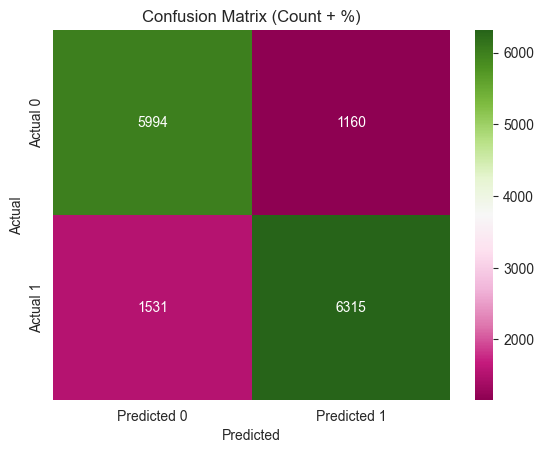

In [117]:
sns.heatmap(cm,annot=True,fmt="d",cmap="PiYG",xticklabels=["Predicted 0", "Predicted 1"],yticklabels=["Actual 0", "Actual 1"])
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.title("Confusion Matrix (Count + %)")
plt.show()

In [118]:
df=pd.DataFrame()
df["Metric"]=pd.Series(["Best CV Score","Testing Score","Training Score","Accuracy Score"])
df["Score"]=pd.Series([best_score, test_score,train_score,acu_score])
df 

,Metric,Score
0,Best CV Score,0.792886
1,Testing Score,0.820600
2,Training Score,0.963171
3,Accuracy Score,0.820600


In [119]:
results_df = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})
results_df["Correct"] = results_df["Actual"] == results_df["Predicted"]
results_df 

,Actual,Predicted,Correct
33553,1,0,False
9427,0,0,True
199,1,1,True
12447,1,1,True
39489,0,0,True
...,...,...,...
15168,1,1,True
49241,1,1,True
39317,0,1,False
42191,0,0,True


In [120]:
import os
import joblib

# Make sure the folder exists
os.makedirs("MY_PROJECT", exist_ok=True)

# Save the trained model
joblib.dump(best_model, "MY_PROJECT/model.pkl")

# Save your scaler (assuming you used MinMaxScaler)
joblib.dump(scaler, "MY_PROJECT/scaler.pkl")
print("Model and scaler saved in 'MY_PROJECT' folder!")

Model and scaler saved in 'MY_PROJECT' folder!


In [121]:
import joblib
joblib.dump(le, "MY_PROJECT/job_le.pkl")          
joblib.dump(li, "MY_PROJECT/marital_le.pkl")     
joblib.dump(lo, "MY_PROJECT/education_le.pkl")    
joblib.dump(lc, "MY_PROJECT/contact_le.pkl")      
joblib.dump(lm, "MY_PROJECT/month_le.pkl")       
joblib.dump(lp, "MY_PROJECT/poutcome_le.pkl")     

binary_mapping = {"default": {"yes": 1, "no": 0},
                  "housing": {"yes": 1, "no": 0},
                  "loan": {"yes": 1, "no": 0}}

joblib.dump(binary_mapping, "MY_PROJECT/binary_mapping.pkl")

['MY_PROJECT/binary_mapping.pkl']

In [ ]:
import joblib
import numpy as np
import warnings
warnings.filterwarnings("ignore")

# Load model and scaler
model = joblib.load("MY_PROJECT/model.pkl")
scaler = joblib.load("MY_PROJECT/scaler.pkl")

job_le = joblib.load("MY_PROJECT/job_le.pkl")
marital_le = joblib.load("MY_PROJECT/marital_le.pkl")
education_le = joblib.load("MY_PROJECT/education_le.pkl")
contact_le = joblib.load("MY_PROJECT/contact_le.pkl")
month_le = joblib.load("MY_PROJECT/month_le.pkl")
poutcome_le = joblib.load("MY_PROJECT/poutcome_le.pkl")

def run_user_prediction():
    print("\n=== Enter Customer Details ===")

    age = int(input("age: "))
    job = job_le.transform([input("job: ")])[0]
    marital = marital_le.transform([input("marital: ")])[0]
    education = education_le.transform([input("education: ")])[0]
    default = int(input("default (0/1): "))
    balance = float(input("balance: "))
    housing = int(input("housing (0/1): "))
    loan = int(input("loan (0/1): "))
    contact = contact_le.transform([input("contact: ")])[0]
    day = int(input("day: "))
    month = month_le.transform([input("month: ")])[0]
    campaign = int(input("campaign: "))
    pdays = int(input("pdays: "))
    previous = int(input("previous: "))
    poutcome = poutcome_le.transform([input("poutcome: ")])[0]
    
    features = np.array([[
        age, job, marital, education, default, balance,
        housing, loan, contact, day, month,
        campaign, pdays, previous, poutcome
    ]])

    features_scaled = scaler.transform(features)
    
    prediction = model.predict(features_scaled)[0]
    prob = model.predict_proba(features_scaled)[0]
    print("\n===== Prediction Result =====")
    if prediction == 1:
        print("✅ Customer WILL subscribe to deposit")
        print("   → This customer is likely to accept the deposit offer.")
        print(f"Probability YES : {prob[1]*100:.2f}%")
    else:
        print("❌ Customer will NOT subscribe")
        print("   → This customer is unlikely to subscribe.")
        print(f"Probability NO  : {prob[0]*100:.2f}%") 
run_user_prediction()


=== Enter Customer Details ===
